# 🌌 Stellar Object Classification using Machine Learning
## ARTI 308 - Machine Learning Course Project
### Imam Abdulrahman Bin Faisal University
---

**Project Goal:** Build a machine learning model to classify astronomical objects into three categories:
- ⭐ **Stars** - Luminous balls of gas (close to Earth)
- 🌌 **Galaxies** - Massive systems of billions of stars (medium distance)
- 💫 **Quasars (QSO)** - Extremely bright galactic nuclei powered by black holes (very far away)

**Dataset:** Sloan Digital Sky Survey DR17 (SDSS) - 100,000 astronomical observations

---
## Section 1: Setup & Import Libraries
---

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')  # Space theme!

print("All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Section 2: Load and Explore Data
---

In [44]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
df = pd.read_csv('star_classification.csv')

print("📊 Dataset Shape:", df.shape)
print(f"   → {df.shape[0]:,} observations")
print(f"   → {df.shape[1]} features")

📊 Dataset Shape: (100000, 18)
   → 100,000 observations
   → 18 features


In [45]:
# First look at the data
print("\n🔍 First 5 rows:")
df.head()


🔍 First 5 rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
# Column information
print("\n Column Names and Data Types:")
print(df.dtypes)


📋 Column Names and Data Types:
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object


In [ ]:
# Check for missing values
print("\n Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values! ✅")


❓ Missing Values:
No missing values! ✅


In [ ]:
# Class distribution
print("\n Target Variable Distribution:")
class_counts = df['class'].value_counts()
print(class_counts)
print(f"\nPercentages:")
print((class_counts / len(df) * 100).round(2).astype(str) + '%')


🎯 Target Variable Distribution:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Percentages:
class
GALAXY    59.44%
STAR      21.59%
QSO       18.96%
Name: count, dtype: object


In [ ]:
# Statistical summary of numerical features
print("\n Statistical Summary:")
df[['u', 'g', 'r', 'i', 'z', 'redshift']].describe().round(3)


📈 Statistical Summary:


,u,g,r,i,z,redshift
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,21.980,20.531,19.646,19.085,18.669,0.577
std,31.769,31.750,1.855,1.758,31.728,0.731
min,-9999.000,-9999.000,9.822,9.470,-9999.000,-0.010
25%,20.352,18.965,18.136,17.732,17.461,0.055
50%,22.179,21.100,20.125,19.405,19.005,0.424
75%,23.687,22.124,21.045,20.396,19.921,0.704
max,32.781,31.602,29.572,32.141,29.384,7.011


---
## Section 3: Data Visualization (EDA)
---

### 3.1 Class Distribution

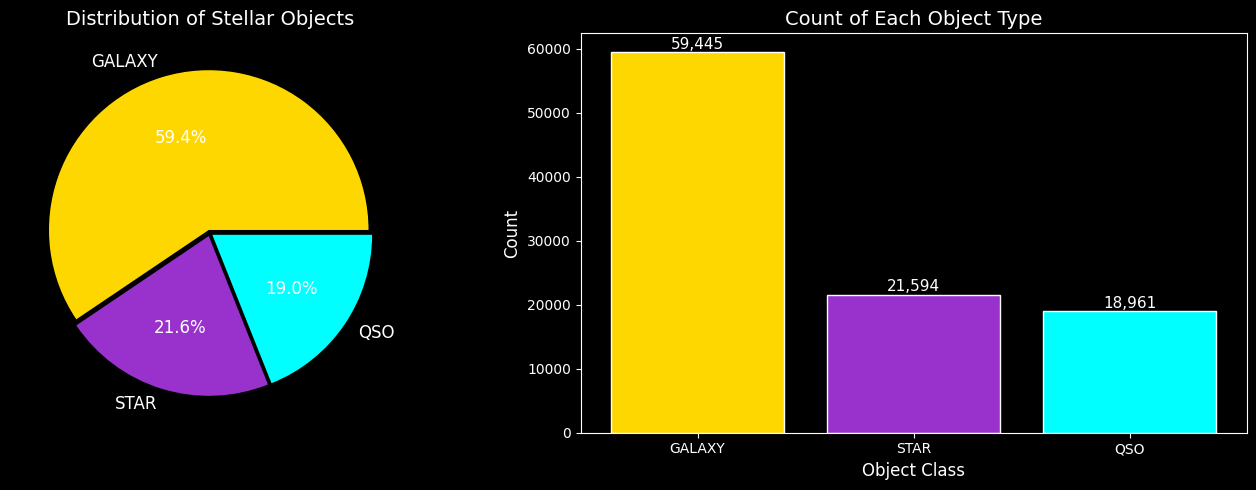

In [50]:
# Pie chart of class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#FFD700', '#9932CC', '#00FFFF']  # Gold, Purple, Cyan
axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.02, 0.02, 0.02],
            textprops={'fontsize': 12, 'color': 'white'})
axes[0].set_title('Distribution of Stellar Objects', fontsize=14, color='white')

# Bar chart
bars = axes[1].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white')
axes[1].set_xlabel('Object Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Count of Each Object Type', fontsize=14)

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                 f'{count:,}', ha='center', fontsize=11, color='white')

plt.tight_layout()
plt.show()

### 3.2 Feature Distributions by Class

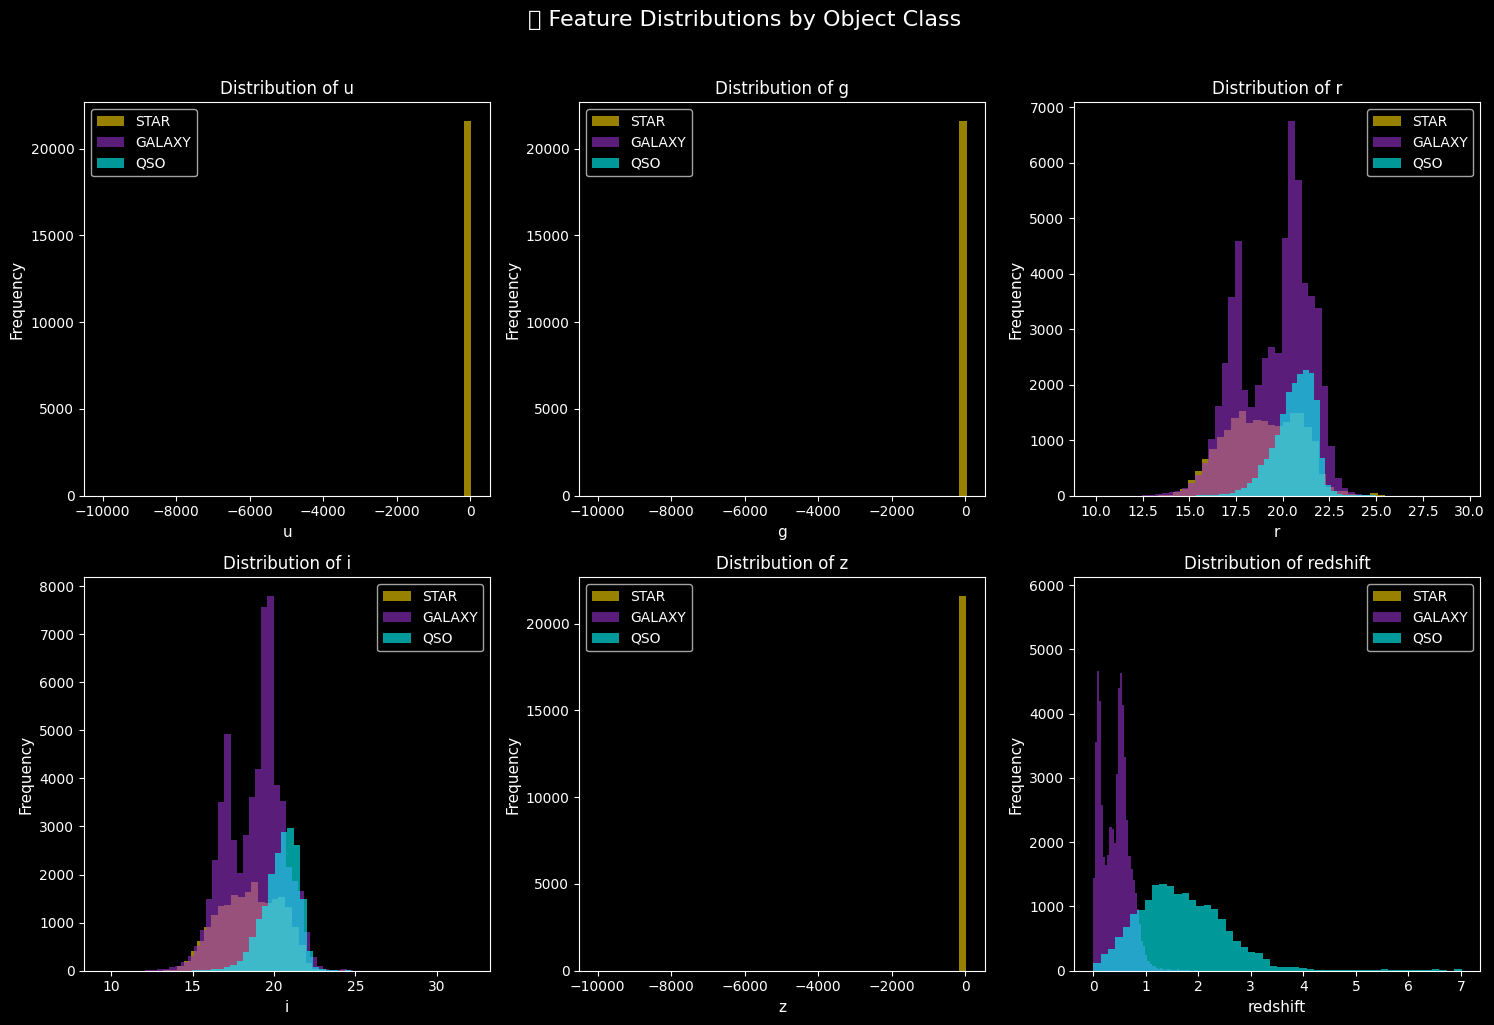

In [ ]:
# Distribution of key features
features = ['u', 'g', 'r', 'i', 'z', 'redshift']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

color_map = {'STAR': '#FFD700', 'GALAXY': '#9932CC', 'QSO': '#00FFFF'}

for idx, feature in enumerate(features):
    for obj_class in ['STAR', 'GALAXY', 'QSO']:
        subset = df[df['class'] == obj_class][feature]
        axes[idx].hist(subset, bins=50, alpha=0.6, label=obj_class, 
                       color=color_map[obj_class], edgecolor='none')
    
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12)
    axes[idx].legend()

plt.suptitle('Feature Distributions by Object Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Redshift Distribution (Most Important Feature!)

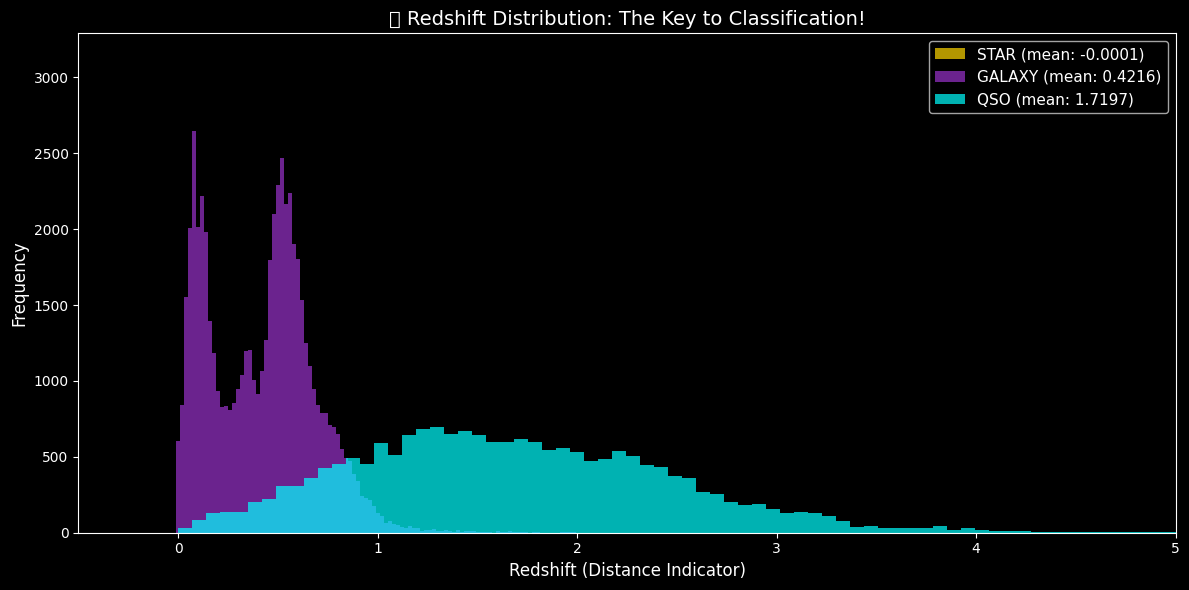

In [52]:
# Redshift comparison - THIS IS KEY!
fig, ax = plt.subplots(figsize=(12, 6))

for obj_class in ['STAR', 'GALAXY', 'QSO']:
    subset = df[df['class'] == obj_class]['redshift']
    ax.hist(subset, bins=100, alpha=0.7, label=f"{obj_class} (mean: {subset.mean():.4f})", 
            color=color_map[obj_class])

ax.set_xlabel('Redshift (Distance Indicator)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('🚀 Redshift Distribution: The Key to Classification!', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(-0.5, 5)

# Add annotations
ax.annotate('Stars are CLOSE\n(low redshift)', xy=(0.05, 15000), fontsize=10, color='#FFD700')
ax.annotate('Quasars are FAR\n(high redshift)', xy=(2.5, 5000), fontsize=10, color='#00FFFF')

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

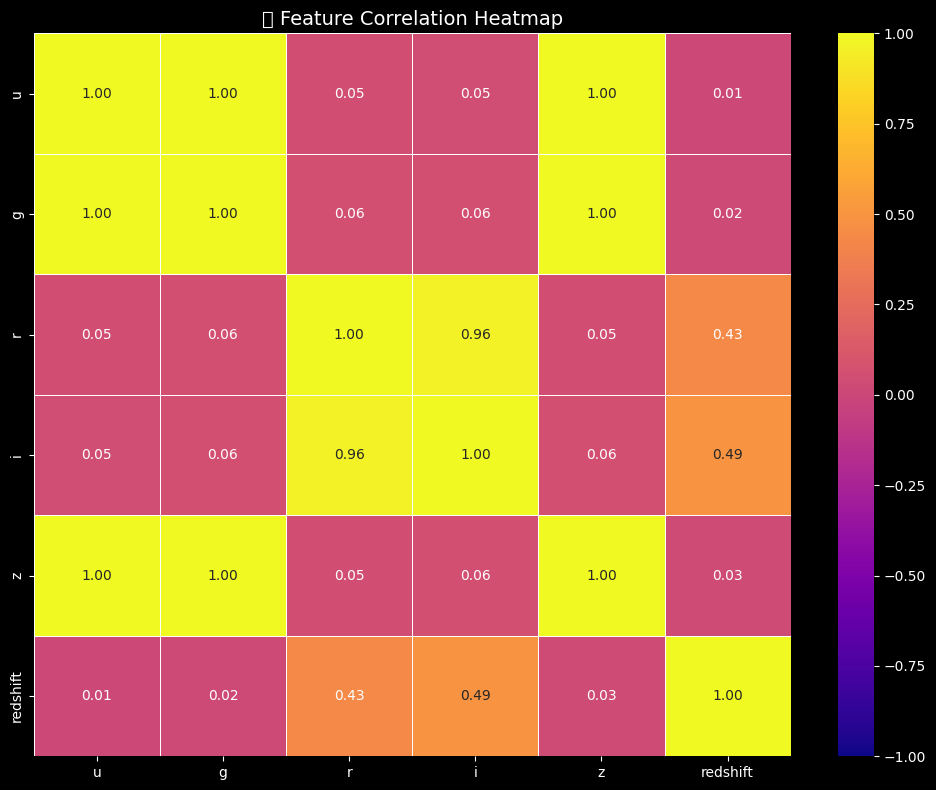


💡 Insight: u, g, r, i, z filters are highly correlated (they all measure light).
   Redshift has lower correlation - it provides UNIQUE information!


In [ ]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))

corr_features = ['u', 'g', 'r', 'i', 'z', 'redshift']
corr_matrix = df[corr_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt='.2f', 
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title(' Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

print("\n💡 Insight: u, g, r, i, z filters are highly correlated (they all measure light).")
print("   Redshift has lower correlation - it provides UNIQUE information!")

### 3.5 ⭐ Interactive 3D Space Map

In [ ]:
# Interactive 3D visualization
sample = df.sample(5000, random_state=42)  # Sample for performance

# Create hover text with details
sample['hover_text'] = (
    '<b>Class: ' + sample['class'] + '</b><br>' +
    '───────────────<br>' +
    '<b>Distance Info:</b><br>' +
    'Redshift: ' + sample['redshift'].round(4).astype(str) + '<br>' +
    '───────────────<br>' +
    '<b>Light Measurements:</b><br>' +
    'u (Ultraviolet): ' + sample['u'].round(2).astype(str) + '<br>' +
    'g (Green): ' + sample['g'].round(2).astype(str) + '<br>' +
    'r (Red): ' + sample['r'].round(2).astype(str) + '<br>' +
    'i (Infrared): ' + sample['i'].round(2).astype(str) + '<br>' +
    'z (Far-IR): ' + sample['z'].round(2).astype(str) + '<br>' +
    '───────────────<br>' +
    '<b>Sky Position:</b><br>' +
    'RA: ' + sample['alpha'].round(2).astype(str) + '°<br>' +
    'Dec: ' + sample['delta'].round(2).astype(str) + '°'
)

# Create 3D plot
fig = go.Figure()

colors_3d = {'STAR': '#FFD700', 'GALAXY': '#9932CC', 'QSO': '#00FFFF'}
sizes_3d = {'STAR': 3, 'GALAXY': 5, 'QSO': 7}

for obj_class in ['STAR', 'GALAXY', 'QSO']:
    subset = sample[sample['class'] == obj_class]
    
    fig.add_trace(go.Scatter3d(
        x=subset['alpha'],
        y=subset['delta'],
        z=subset['redshift'],
        mode='markers',
        name=obj_class,
        marker=dict(
            size=sizes_3d[obj_class],
            color=colors_3d[obj_class],
            opacity=0.8,
            line=dict(width=0.5, color='white')
        ),
        hovertemplate='%{text}<extra></extra>',
        text=subset['hover_text']
    ))

# Style like space
# Style like space
    fig.update_layout(
        title=dict(
            text=' Interactive 3D Map of Space - Hover to Explore!',
            font=dict(size=20, color='white')
        ),
        scene=dict(
            xaxis=dict(title='Right Ascension (°)', backgroundcolor='black', 
                    gridcolor='#333333', color='white'),
            yaxis=dict(title='Declination (°)', backgroundcolor='black', 
                    gridcolor='#333333', color='white'),
            zaxis=dict(title='Redshift (Distance)', backgroundcolor='black', 
                    gridcolor='#333333', color='white'),
            bgcolor='black',
            # ADD THIS PART 
            camera=dict(
                eye=dict(x=0.65, y=0.65, z=0.65)  # Starting zoom level (smaller = closer)
            )
        ),
        #Makes scrolling faster
        scene_dragmode='orbit',
        paper_bgcolor='black',
        font=dict(color='white'),
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01,
                    bgcolor='rgba(0,0,0,0.7)', font=dict(size=12)),
        height=700
    )

fig.show()

print("\n Controls: Drag to rotate | Scroll to zoom | Hover for details")


🖱️ Controls: Drag to rotate | Scroll to zoom | Hover for details


### 3.6 Light Signatures Comparison

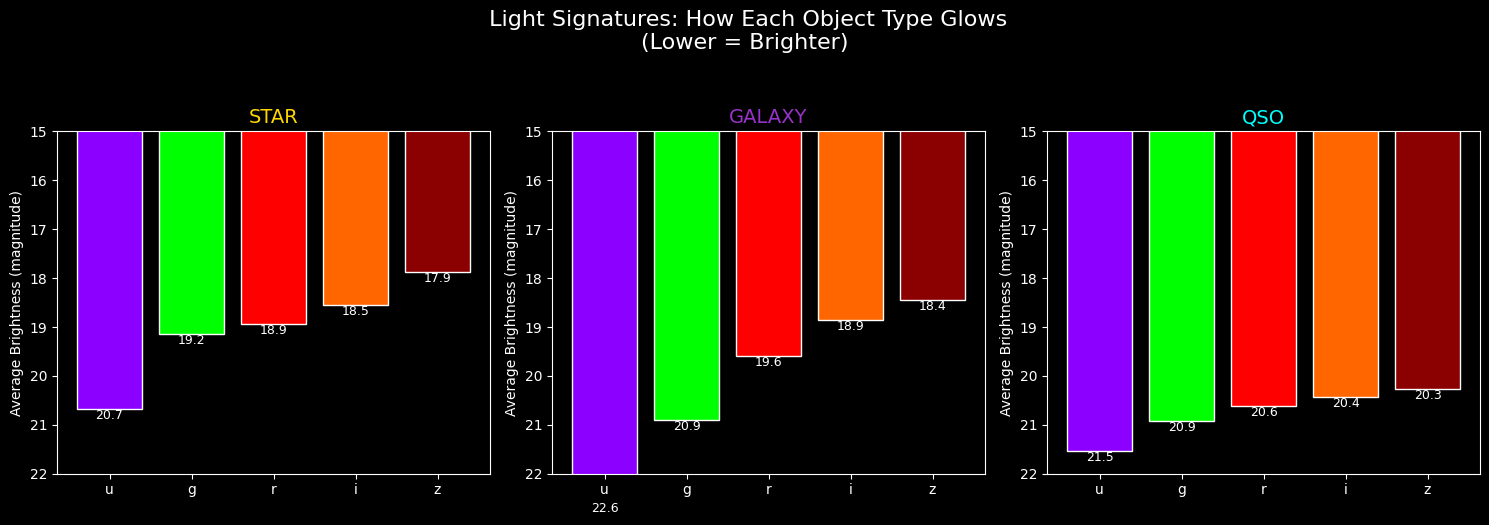

In [307]:
# Average light signature per class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

filters = ['u', 'g', 'r', 'i', 'z']
filter_colors = ['#8B00FF', '#00FF00', '#FF0000', '#FF6600', '#8B0000']

for idx, obj_class in enumerate(['STAR', 'GALAXY', 'QSO']):
    means = df[df['class'] == obj_class][filters].mean()
    
    bars = axes[idx].bar(filters, means.values, color=filter_colors, edgecolor='white')
    axes[idx].set_title(f'{obj_class}', fontsize=14, color=colors_3d[obj_class])
    axes[idx].set_ylabel('Average Brightness (magnitude)')
    axes[idx].set_ylim(15, 22)
    axes[idx].invert_yaxis()  # Lower magnitude = brighter
    
    # Add value labels
    for bar, val in zip(bars, means.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, val + 0.2, 
                       f'{val:.1f}', ha='center', fontsize=9, color='white')

plt.suptitle(' Light Signatures: How Each Object Type Glows\n(Lower = Brighter)', 
             fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

---
## Section 4: Data Preprocessing
---

In [ ]:
# Select features for our model
feature_columns = ['u', 'g', 'r', 'i', 'z', 'redshift']
target_column = 'class'

X = df[feature_columns]
y = df[target_column]

print(" Features shape:", X.shape)
print(" Target shape:", y.shape)
print("\n Features used:", feature_columns)

📊 Features shape: (100000, 6)
🎯 Target shape: (100000,)

📋 Features used: ['u', 'g', 'r', 'i', 'z', 'redshift']


In [ ]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(" Label Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"   {label} → {i}")

🏷️ Label Encoding:
   GALAXY → 0
   QSO → 1
   STAR → 2


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # For reproducibility
    stratify=y_encoded  # Maintain class proportions
)

print(" Data Split:")
print(f"   Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Testing set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

✂️ Data Split:
   Training set: 80,000 samples (80%)
   Testing set:  20,000 samples (20%)


In [ ]:
# Scale features (important for some algorithms like SVM and k-NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled using StandardScaler")
print("   (Mean = 0, Standard Deviation = 1)")

⚖️ Features scaled using StandardScaler
   (Mean = 0, Standard Deviation = 1)


---
## Section 5: Train Machine Learning Models
---

In [ ]:
# Dictionary to store results
results = {}

print(" Training Models...\n")
print("=" * 50)

🚀 Training Models...



### 5.1 Logistic Regression

In [ ]:
# Logistic Regression
print("\n📌 Model 1: Logistic Regression")
print("-" * 40)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

results['Logistic Regression'] = lr_accuracy
print(f"✅ Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")


📌 Model 1: Logistic Regression
----------------------------------------
✅ Accuracy: 0.9551 (95.51%)


### 5.2 Decision Tree

In [314]:
# Decision Tree
print("\n📌 Model 2: Decision Tree")
print("-" * 40)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)  # Decision Trees don't need scaling
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

results['Decision Tree'] = dt_accuracy
print(f"✅ Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")


📌 Model 2: Decision Tree
----------------------------------------
✅ Accuracy: 0.9757 (97.57%)


### 5.3 Random Forest

In [315]:
# Random Forest
print("\n📌 Model 3: Random Forest")
print("-" * 40)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

results['Random Forest'] = rf_accuracy
print(f"✅ Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")


📌 Model 3: Random Forest
----------------------------------------
✅ Accuracy: 0.9800 (98.00%)


### 5.4 K-Nearest Neighbors (k-NN)

In [316]:
# K-Nearest Neighbors
print("\n📌 Model 4: K-Nearest Neighbors (k-NN)")
print("-" * 40)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)  # k-NN needs scaling
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

results['K-Nearest Neighbors'] = knn_accuracy
print(f"✅ Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")


📌 Model 4: K-Nearest Neighbors (k-NN)
----------------------------------------
✅ Accuracy: 0.9654 (96.54%)


### 5.5 Support Vector Machine (SVM)

In [317]:
# Support Vector Machine (using a sample for speed)
print("\n📌 Model 5: Support Vector Machine (SVM)")
print("-" * 40)

# SVM can be slow on large datasets, so we use a subset
sample_size = 20000
idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_train_svm = X_train_scaled[idx]
y_train_svm = y_train.iloc[idx] if hasattr(y_train, 'iloc') else y_train[idx]

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

results['SVM'] = svm_accuracy
print(f"✅ Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"   (Trained on {sample_size:,} samples for efficiency)")


📌 Model 5: Support Vector Machine (SVM)
----------------------------------------
✅ Accuracy: 0.9584 (95.84%)
   (Trained on 20,000 samples for efficiency)


---
## Section 6: Model Evaluation & Comparison
---

### 6.1 Accuracy Comparison

In [318]:
# Summary of all results
print("\n" + "=" * 50)
print("📊 MODEL COMPARISON SUMMARY")
print("=" * 50)

results_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': results.values()
}).sort_values('Accuracy', ascending=False)

results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2).astype(str) + '%'
results_df['Rank'] = range(1, len(results_df) + 1)
results_df = results_df[['Rank', 'Model', 'Accuracy', 'Accuracy %']]

print(results_df.to_string(index=False))

best_model = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
print(f"\n🏆 Best Model: {best_model} with {best_accuracy*100:.2f}% accuracy!")


📊 MODEL COMPARISON SUMMARY
 Rank               Model  Accuracy Accuracy %
    1       Random Forest   0.98000      98.0%
    2       Decision Tree   0.97570     97.57%
    3 K-Nearest Neighbors   0.96535     96.54%
    4                 SVM   0.95840     95.84%
    5 Logistic Regression   0.95510     95.51%

🏆 Best Model: Random Forest with 98.00% accuracy!


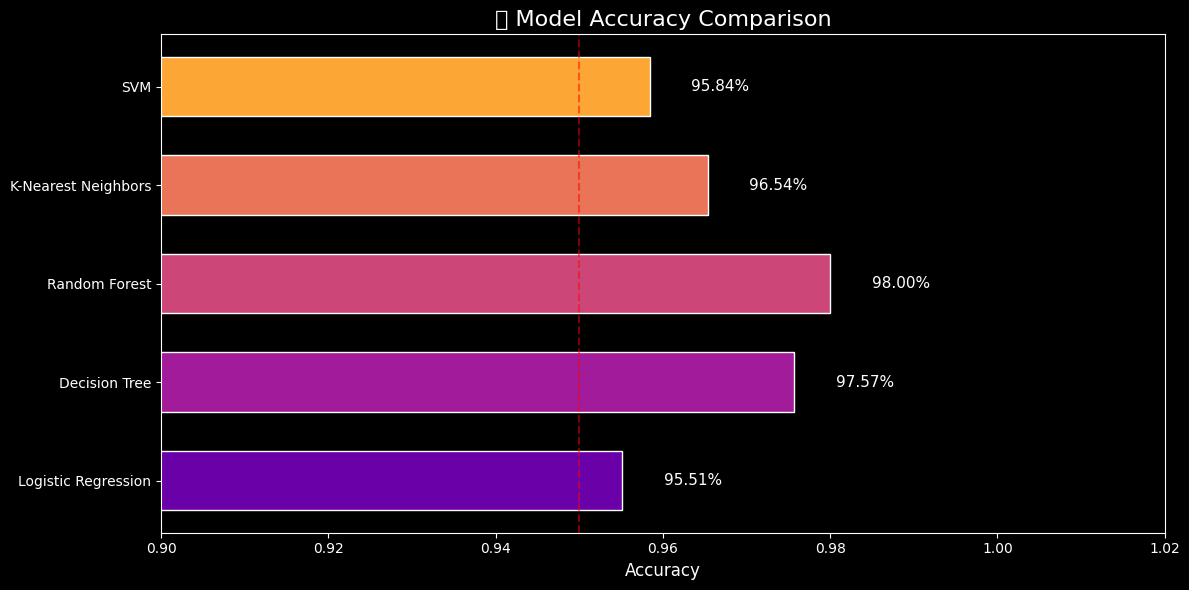

In [319]:
# Visualization of model comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(results.keys())
accuracies = list(results.values())

# Create gradient colors based on accuracy
colors_bar = plt.cm.plasma(np.linspace(0.2, 0.8, len(models)))

bars = ax.barh(models, accuracies, color=colors_bar, edgecolor='white', height=0.6)

# Add accuracy labels
for bar, acc in zip(bars, accuracies):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{acc*100:.2f}%', va='center', fontsize=11, color='white')

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('🏆 Model Accuracy Comparison', fontsize=16)
ax.set_xlim(0.9, 1.02)
ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')

plt.tight_layout()
plt.show()

### 6.2 Confusion Matrix (Best Model)

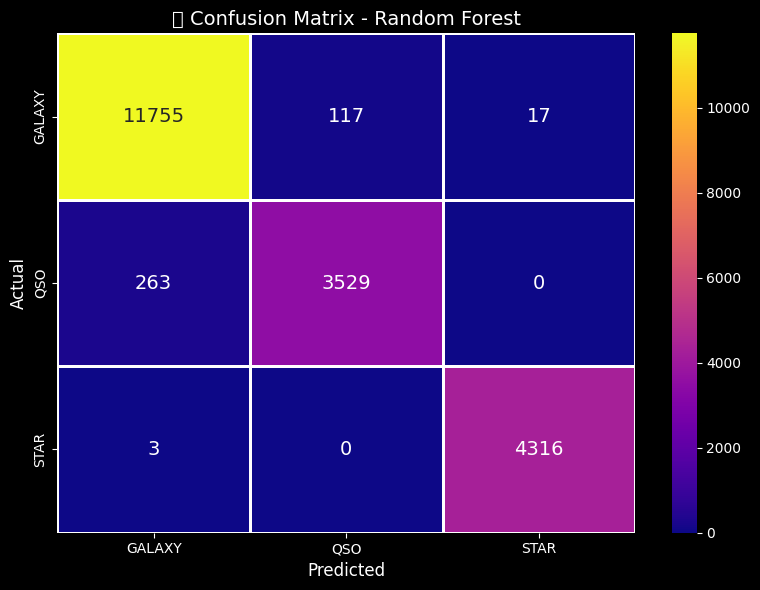


💡 Reading the Confusion Matrix:
   - Diagonal values = Correct predictions
   - Off-diagonal values = Misclassifications


In [ ]:
# Confusion Matrix for the best model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='plasma',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={'size': 14},
            linewidths=2, linecolor='white',
            ax=ax)

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(' Confusion Matrix - Random Forest', fontsize=14)

plt.tight_layout()
plt.show()

print("\n💡 Reading the Confusion Matrix:")
print("   - Diagonal values = Correct predictions")
print("   - Off-diagonal values = Misclassifications")

### 6.3 Classification Report

In [ ]:
# Detailed classification report
print("\n📋 CLASSIFICATION REPORT (Random Forest)")
print("=" * 55)
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))


📋 CLASSIFICATION REPORT (Random Forest)
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



---
## Section 7: Feature Importance
---

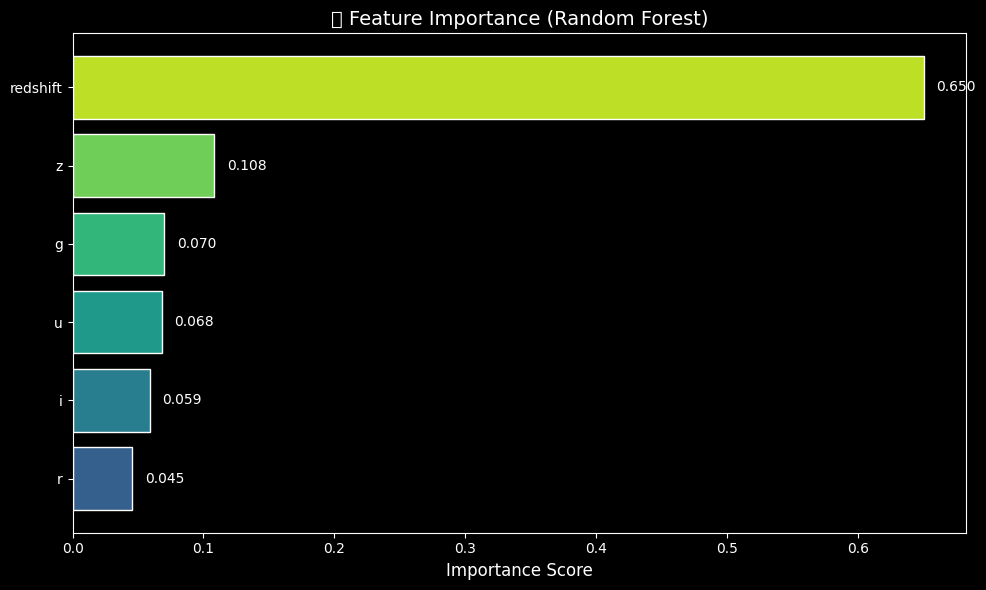


💡 Key Insight:
   REDSHIFT is the most important feature!
   This confirms our earlier observation - distance matters most.


In [ ]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_columns)))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], 
               color=colors_fi, edgecolor='white')

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=10, color='white')

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(' Feature Importance (Random Forest)', fontsize=14)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print(f"   REDSHIFT is the most important feature!")
print(f"   This confirms our earlier observation - distance matters most.")

---
## Section 8: Conclusion
---

In [323]:
print("\n" + "="*60)
print("🌌 PROJECT CONCLUSION")
print("="*60)

print(f"""
📊 Dataset: SDSS DR17 Stellar Classification
   - Total samples: {len(df):,}
   - Features used: {len(feature_columns)} (u, g, r, i, z, redshift)
   - Classes: 3 (Star, Galaxy, Quasar)

🏆 Best Performing Model: {best_model}
   - Accuracy: {best_accuracy*100:.2f}%
   
🔑 Key Findings:
   1. Redshift is the most important feature for classification
   2. Stars have very low redshift (close to Earth)
   3. Quasars have high redshift (billions of light-years away)
   4. The u, g, r, i, z color filters provide complementary information
   5. Random Forest achieved the best balance of accuracy and speed

🎯 Model Performance Summary:
""")

for idx, row in results_df.iterrows():
    emoji = "🥇" if row['Rank'] == 1 else "🥈" if row['Rank'] == 2 else "🥉" if row['Rank'] == 3 else "  "
    print(f"   {emoji} {row['Model']}: {row['Accuracy %']}")

print("\n" + "="*60)
print("✅ Project Complete!")
print("="*60)


🌌 PROJECT CONCLUSION

📊 Dataset: SDSS DR17 Stellar Classification
   - Total samples: 100,000
   - Features used: 6 (u, g, r, i, z, redshift)
   - Classes: 3 (Star, Galaxy, Quasar)

🏆 Best Performing Model: Random Forest
   - Accuracy: 98.00%
   
🔑 Key Findings:
   1. Redshift is the most important feature for classification
   2. Stars have very low redshift (close to Earth)
   3. Quasars have high redshift (billions of light-years away)
   4. The u, g, r, i, z color filters provide complementary information
   5. Random Forest achieved the best balance of accuracy and speed

🎯 Model Performance Summary:

   🥇 Random Forest: 98.0%
   🥈 Decision Tree: 97.57%
   🥉 K-Nearest Neighbors: 96.54%
      SVM: 95.84%
      Logistic Regression: 95.51%

✅ Project Complete!


---
## 📚 References
---

1. Fedesoriano. (2022). Stellar Classification Dataset - SDSS17. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17

2. Sloan Digital Sky Survey. (n.d.). SDSS Home. https://www.sdss.org/

3. Scikit-learn Documentation. https://scikit-learn.org/stable/

4. Plotly Python Graphing Library. https://plotly.com/python/